In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from torchvision.transforms import functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import copy
import random
from PIL import Image

# ============================================
# 1. CONFIGURATION
# ============================================
BASE_DIR = "models/archive/Wound_dataset"   # UPDATE THIS PATH
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 50
NUM_CLASSES = 7
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class names – must match folder names
CLASS_NAMES = ['Abrasions', 'Bruises', 'Burns', 'Cut', 
               'Ingrown_nails', 'Laceration', 'Stab_wound']

# ============================================
# 2. BUILD DATAFRAME WITH ALL IMAGES
# ============================================
filepaths = []
labels = []

for class_name in CLASS_NAMES:
    class_dir = os.path.join(BASE_DIR, class_name)
    if not os.path.exists(class_dir):
        print(f"Warning: {class_dir} not found!")
        continue
    for fname in os.listdir(class_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            filepaths.append(os.path.join(class_dir, fname))
            labels.append(class_name)

print(f"Total images found: {len(filepaths)}")

# Create DataFrame
df = pd.DataFrame({'filename': filepaths, 'label': labels})
print(df['label'].value_counts())   # check class distribution

# ============================================
# 3. SPLIT INTO TRAIN, VAL, TEST (stratified)
# ============================================
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df['label'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Map class names to integer indices
class_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
train_df['label_idx'] = train_df['label'].map(class_to_idx)
val_df['label_idx'] = val_df['label'].map(class_to_idx)
test_df['label_idx'] = test_df['label'].map(class_to_idx)

# ============================================
# 4. CUSTOM DATASET CLASS
# ============================================
class WoundDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = row['filename']
        label = row['label_idx']
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# ============================================
# 5. DATA TRANSFORMS (AUGMENTATION)
# ============================================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(30),
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), shear=0.2),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = WoundDataset(train_df, transform=train_transform)
val_dataset   = WoundDataset(val_df, transform=val_test_transform)
test_dataset  = WoundDataset(test_df, transform=val_test_transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ============================================
# 6. BUILD MODEL (ResNet50 pretrained)
# ============================================
def build_model(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False
    # Replace classifier head
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, num_classes)
    )
    return model

model = build_model(NUM_CLASSES).to(DEVICE)

# ============================================
# 7. LOSS, OPTIMIZER, SCHEDULER
# ============================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.2, patience=5, min_lr=1e-7, verbose=True)

# ============================================
# 8. TRAINING LOOP WITH EARLY STOPPING & CHECKPOINT
# ============================================
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
patience_counter = 0
early_stop_patience = 10

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(EPOCHS):
    # Training phase
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]')
    for images, labels in progress_bar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        progress_bar.set_postfix({'loss': loss.item(), 'acc': correct/total})

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Learning rate scheduler (ReduceLROnPlateau)
    scheduler.step(val_loss)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, 'best_wound_model.pth')
        print(f"  -> New best model saved with val_acc={val_acc:.4f}")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print("Early stopping triggered.")
            break

# Load best model weights
model.load_state_dict(best_model_wts)

# ============================================
# 9. PLOT TRAINING HISTORY
# ============================================
def plot_history(train_loss, val_loss, train_acc, val_acc):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(train_loss, label='Train Loss')
    ax1.plot(val_loss, label='Val Loss')
    ax1.set_title('Loss')
    ax1.legend()
    ax2.plot(train_acc, label='Train Acc')
    ax2.plot(val_acc, label='Val Acc')
    ax2.set_title('Accuracy')
    ax2.legend()
    plt.show()

plot_history(train_losses, val_losses, train_accs, val_accs)

# ============================================
# 10. EVALUATE ON TEST SET
# ============================================
def evaluate_model(model, test_loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Testing'):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Accuracy
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"Test Accuracy: {acc:.4f}")

    # Classification report
    print("\n" + "="*60)
    print("CLASSIFICATION REPORT (Test Set)")
    print("="*60)
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - Test Set')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

evaluate_model(model, test_loader, CLASS_NAMES)

# ============================================
# 11. PREDICT ON A SINGLE IMAGE
# ============================================
def predict_image(image_path, model, class_names, device=DEVICE):
    img = Image.open(image_path).convert('RGB')
    transform = val_test_transform  # same as validation (no augmentation)
    img_tensor = transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        conf, pred = torch.max(probs, 1)
    return class_names[pred.item()], conf.item()

# Example usage:
# cls, conf = predict_image("test_image.jpg", model, CLASS_NAMES)
# print(f"Predicted: {cls} (confidence: {conf:.4f})")

# ============================================
# 12. (OPTIONAL) FINE-TUNING
# ============================================
# If you want to fine-tune, you can unfreeze some layers:
# def fine_tune(model, train_loader, val_loader, epochs=20):
#     # Unfreeze last 10 layers
#     for param in model.parameters():
#         param.requires_grad = True
#     # Freeze earlier layers
#     for name, param in model.named_parameters():
#         if 'layer4' not in name and 'fc' not in name:
#             param.requires_grad = False
#     optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
#     # ... continue training loop ...
#     return model

# Uncomment and modify as needed.

Total images found: 0
Series([], Name: count, dtype: int64)


ValueError: With n_samples=0, test_size=0.3 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

Using device: cuda
Total images found: 431

Class distribution:
label
Bruises          122
Abrasions         85
Laceration        61
Burns             59
Cut               50
Ingrown_nails     31
Stab_wound        23
Name: count, dtype: int64

Train: 301, Val: 65, Test: 65


c:\Users\adelu\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 1/50 [Train]: 100%|██████████| 19/19 [00:06<00:00,  2.74it/s, loss=1.73, acc=0.223]


Epoch 1/50 - Train Loss: 1.8958, Train Acc: 0.2226 | Val Loss: 1.8636, Val Acc: 0.2769
  -> New best model saved with val_acc=0.2769


Epoch 2/50 [Train]: 100%|██████████| 19/19 [00:03<00:00,  4.95it/s, loss=1.84, acc=0.269]


Epoch 2/50 - Train Loss: 1.8193, Train Acc: 0.2691 | Val Loss: 1.8288, Val Acc: 0.2769


...

Epoch 48/50 - Train Loss: 1.0004, Train Acc: 0.6445 | Val Loss: 0.9851, Val Acc: 0.6769


Epoch 49/50 [Train]: 100%|██████████| 19/19 [00:03<00:00,  5.75it/s, loss=0.985, acc=0.638]


Epoch 49/50 - Train Loss: 0.9767, Train Acc: 0.6379 | Val Loss: 0.9930, Val Acc: 0.6769


Epoch 50/50 [Train]: 100%|██████████| 19/19 [00:03<00:00,  5.95it/s, loss=1.03, acc=0.671] 


Epoch 50/50 - Train Loss: 0.9509, Train Acc: 0.6711 | Val Loss: 0.9774, Val Acc: 0.6615


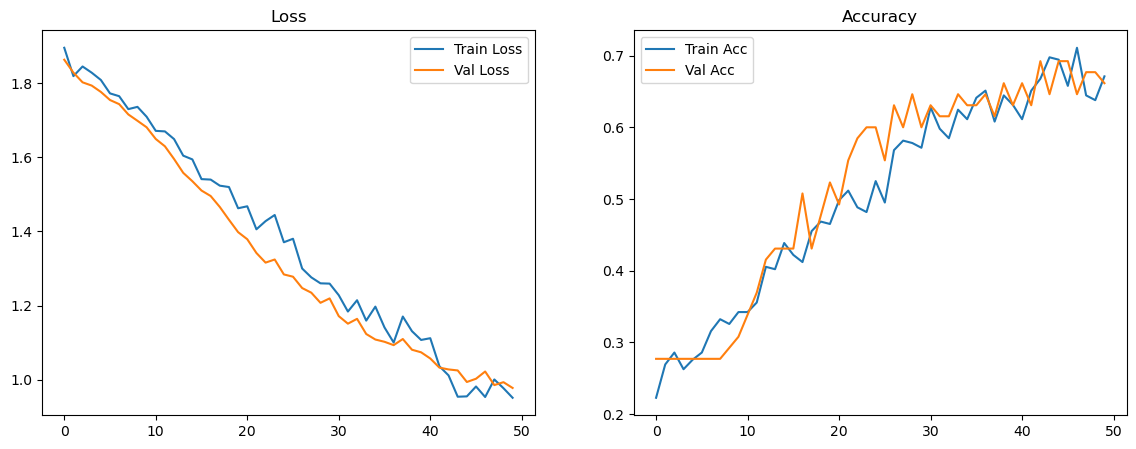

Testing: 100%|██████████| 5/5 [00:01<00:00,  3.89it/s]
c:\Users\adelu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\adelu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\adelu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

Test Accuracy: 0.6308

CLASSIFICATION REPORT (Test Set)
               precision    recall  f1-score   support

    Abrasions       0.67      0.62      0.64        13
      Bruises       0.83      0.79      0.81        19
        Burns       0.75      0.67      0.71         9
          Cut       0.31      0.57      0.40         7
Ingrown_nails       0.50      0.40      0.44         5
   Laceration       0.60      0.67      0.63         9
   Stab_wound       0.00      0.00      0.00         3

     accuracy                           0.63        65
    macro avg       0.52      0.53      0.52        65
 weighted avg       0.64      0.63      0.63        65



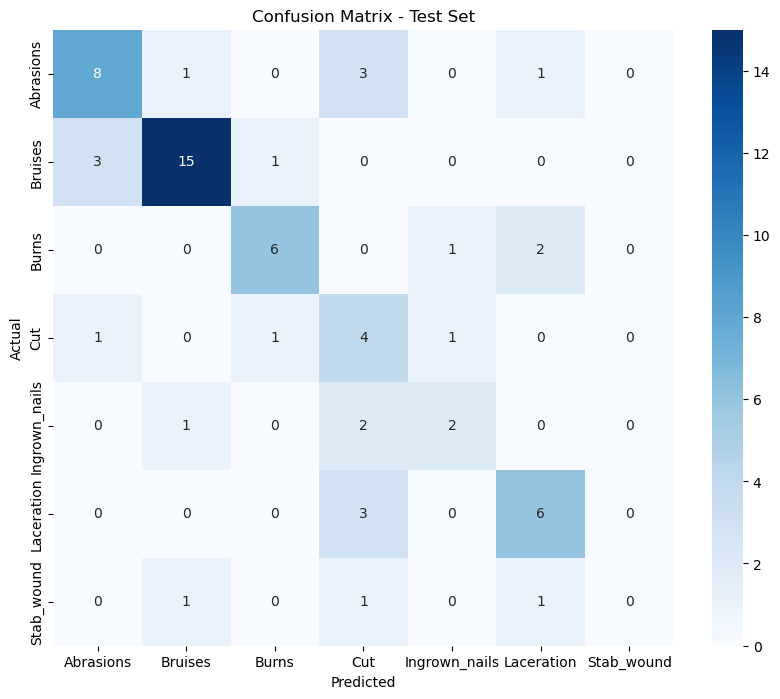


Training complete! Model saved as 'best_wound_model.pth'


In [5]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import copy
from PIL import Image

# ============================================
# 1. CONFIGURATION
# ============================================
# ⚠️ IMPORTANT: CHANGE THIS TO YOUR ACTUAL DATASET PATH
BASE_DIR = r"C:/Users/adelu/OneDrive/Documents/AVASOFT-HEALTH/models/archive/Wound_dataset"   # Example: if the folder is in the same directory as this script
# For absolute path on Windows: BASE_DIR = r"C:\Users\YourName\Downloads\Wound_dataset"
# For relative path: BASE_DIR = "models/archive/Wound_dataset"

# Check if the directory exists
if not os.path.exists(BASE_DIR):
    print(f"ERROR: Directory '{BASE_DIR}' not found!")
    print(f"Current working directory: {os.getcwd()}")
    print("Available folders here:")
    for item in os.listdir('.'):
        if os.path.isdir(item):
            print(f"  - {item}")
    raise FileNotFoundError(f"Please set BASE_DIR to the correct path.")

# Verify that the class folders are inside
class_folders = ['Abrasions', 'Bruises', 'Burns', 'Cut', 'Ingrown_nails', 'Laceration', 'Stab_wound']
missing = [f for f in class_folders if not os.path.exists(os.path.join(BASE_DIR, f))]
if missing:
    print(f"WARNING: The following class folders are missing: {missing}")
    print("Make sure the dataset structure is:")
    print("  Wound_dataset/")
    for f in class_folders:
        print(f"    {f}/")
    print("If your folder names differ, update the CLASS_NAMES list below.")

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 50
NUM_CLASSES = 7
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Class names – must match folder names exactly
CLASS_NAMES = ['Abrasions', 'Bruises', 'Burns', 'Cut', 
               'Ingrown_nails', 'Laceration', 'Stab_wound']

# ============================================
# 2. BUILD DATAFRAME WITH ALL IMAGES
# ============================================
filepaths = []
labels = []

for class_name in CLASS_NAMES:
    class_dir = os.path.join(BASE_DIR, class_name)
    if not os.path.exists(class_dir):
        print(f"Warning: {class_dir} not found! Skipping.")
        continue
    for fname in os.listdir(class_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            filepaths.append(os.path.join(class_dir, fname))
            labels.append(class_name)

print(f"Total images found: {len(filepaths)}")
if len(filepaths) == 0:
    raise RuntimeError("No images found. Check your BASE_DIR and folder structure.")

# Create DataFrame
df = pd.DataFrame({'filename': filepaths, 'label': labels})
print("\nClass distribution:")
print(df['label'].value_counts())

# ============================================
# 3. SPLIT INTO TRAIN, VAL, TEST (stratified)
# ============================================
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df['label'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42
)

print(f"\nTrain: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Map class names to integer indices
class_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
train_df['label_idx'] = train_df['label'].map(class_to_idx)
val_df['label_idx'] = val_df['label'].map(class_to_idx)
test_df['label_idx'] = test_df['label'].map(class_to_idx)

# ============================================
# 4. CUSTOM DATASET CLASS
# ============================================
class WoundDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = row['filename']
        label = row['label_idx']
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# ============================================
# 5. DATA TRANSFORMS (AUGMENTATION)
# ============================================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(30),
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), shear=0.2),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = WoundDataset(train_df, transform=train_transform)
val_dataset   = WoundDataset(val_df, transform=val_test_transform)
test_dataset  = WoundDataset(test_df, transform=val_test_transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ============================================
# 6. BUILD MODEL (ResNet50 pretrained)
# ============================================
def build_model(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False
    # Replace classifier head
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, num_classes)
    )
    return model

model = build_model(NUM_CLASSES).to(DEVICE)

# ============================================
# 7. LOSS, OPTIMIZER, SCHEDULER
# ============================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.2, patience=5, min_lr=1e-7, verbose=True)

# ============================================
# 8. TRAINING LOOP WITH EARLY STOPPING & CHECKPOINT
# ============================================
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
patience_counter = 0
early_stop_patience = 10

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(EPOCHS):
    # Training phase
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]')
    for images, labels in progress_bar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        progress_bar.set_postfix({'loss': loss.item(), 'acc': correct/total})

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Learning rate scheduler (ReduceLROnPlateau)
    scheduler.step(val_loss)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, 'best_wound_model.pth')
        print(f"  -> New best model saved with val_acc={val_acc:.4f}")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print("Early stopping triggered.")
            break

# Load best model weights
model.load_state_dict(best_model_wts)

# ============================================
# 9. PLOT TRAINING HISTORY
# ============================================
def plot_history(train_loss, val_loss, train_acc, val_acc):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(train_loss, label='Train Loss')
    ax1.plot(val_loss, label='Val Loss')
    ax1.set_title('Loss')
    ax1.legend()
    ax2.plot(train_acc, label='Train Acc')
    ax2.plot(val_acc, label='Val Acc')
    ax2.set_title('Accuracy')
    ax2.legend()
    plt.show()

plot_history(train_losses, val_losses, train_accs, val_accs)

# ============================================
# 10. EVALUATE ON TEST SET
# ============================================
def evaluate_model(model, test_loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Testing'):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Accuracy
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"Test Accuracy: {acc:.4f}")

    # Classification report
    print("\n" + "="*60)
    print("CLASSIFICATION REPORT (Test Set)")
    print("="*60)
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - Test Set')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

evaluate_model(model, test_loader, CLASS_NAMES)

# ============================================
# 11. PREDICT ON A SINGLE IMAGE
# ============================================
def predict_image(image_path, model, class_names, device=DEVICE):
    img = Image.open(image_path).convert('RGB')
    transform = val_test_transform
    img_tensor = transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        conf, pred = torch.max(probs, 1)
    return class_names[pred.item()], conf.item()

# Example usage:
# cls, conf = predict_image("test_image.jpg", model, CLASS_NAMES)
# print(f"Predicted: {cls} (confidence: {conf:.4f})")

# ============================================
# 12. (OPTIONAL) FINE-TUNING
# ============================================
# If you want to fine-tune after training, uncomment and modify.
# def fine_tune(model, train_loader, val_loader, epochs=20):
#     # Unfreeze the last few layers
#     for param in model.parameters():
#         param.requires_grad = True
#     # Freeze all layers except layer4 and fc
#     for name, param in model.named_parameters():
#         if 'layer4' not in name and 'fc' not in name:
#             param.requires_grad = False
#     optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
#     # ... (copy training loop with lower lr)
#     return model

print("\nTraining complete! Model saved as 'best_wound_model.pth'")